In [1]:
import os
import re

import numpy as np
import torch
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import pickle
from tqdm.notebook import tqdm
from functionsgpu_old import *
from plotting_betas import *
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from video_saving import *

mpl.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "legend.title_fontsize": 14,
    "figure.titlesize": 17,
})

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(device)
dtype = torch.float32
SEED = 42

def deterministic():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    # Enable deterministic operations (may slow down training slightly)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

deterministic()
tslen = 200

cuda:1


In [2]:
def loading(filename, tslen):
    with open('{}/betas_aligned{}.pkl'.format(filename, tslen), 'rb') as f:
        betas_aligned = pickle.load(f)
    with open('{}/mu{}.pkl'.format(filename, tslen), 'rb') as f:
        mu = pickle.load(f)
    with open('{}/tangent_vecs{}.pkl'.format(filename, tslen), 'rb') as f:
        tangent_vec_all = pickle.load(f)
    return betas_aligned, mu, tangent_vec_all

betas_aligned_all, mu_all_t, tangent_vec_all = loading('aligned_data',tslen)
mu_all_t_tensor = torch.from_numpy(mu_all_t).to(device=device, dtype=torch.float32)
print(len(betas_aligned_all), tangent_vec_all.shape, mu_all_t.shape)

155 (32, 3, 200, 155) (32, 3, 200)


In [3]:
participant_ids = np.loadtxt('pids.txt')
demo_df = pd.read_csv('demo_data.csv')
id_to_lesion = dict(zip(demo_df['s'].astype(int), demo_df['LesionLeft']))
y_lesion = np.array([id_to_lesion[int(pid)] for pid in participant_ids])

print("y_lesion shape:", y_lesion.shape)

y_lesion shape: (155,)


In [4]:
K = 32
M = 3
T = tslen
nsamples = 155

tangent_flat = tangent_vec_all.reshape((K*M*T, nsamples))
print(tangent_flat.shape)

(19200, 155)


## VAE

In [5]:
class NonlinearVAE(nn.Module):
    """NonlinearVAE"""
    def __init__(self, D, R, H=128, dropout=0.1):
        super().__init__()
        # Encoder layers
        self.W1 = nn.Linear(D, H, bias=False)        # input -> hidden
        self.W2_mu = nn.Linear(H, R, bias=False)     # hidden -> latent mean
        self.W2_logvar = nn.Linear(H, R)             # hidden -> latent logvar
        self.dropout = nn.Dropout(p=dropout)
        
        # Decoder layers
        self.dec1 = nn.Linear(R, 16, bias=False)
        self.dec2 = nn.Linear(16, D, bias=False)

    def encode(self, x):
        h = torch.tanh(self.W1(x))
        h = self.dropout(h)
        mu = self.W2_mu(h)
        logvar = self.W2_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h_recon = torch.tanh(self.dec1(z))
        x_hat = self.dec2(h_recon)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar, z


def vae_loss(x, x_hat, mu, logvar, beta=1e-4):
    dist = (x-x_hat)**2
    recon = torch.mean(dist.sum(dim=1))
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    avg_kl = kl.mean()
    return recon + beta * avg_kl, recon, avg_kl

def ktrsv_loss(x_man, x_hat_man, mu, logvar, beta=1e-4):
    dist = squared_geodesic_distance(x_man, x_hat_man, K, M, T)
    recon = torch.mean(dist.sum(dim=1))
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    avg_kl = kl.mean()
    return recon + beta * avg_kl, recon, avg_kl


## KTRSV

In [6]:
class KTRSV(nn.Module):
    """rVAE: encode tangent vectors, decode to tangent, but (during
    training) compare reconstructions on the manifold via an exp map.

    - Inputs: tangent vectors (N, D) as in the VAE section.
    - Decoder: produces tangent vectors.
    - Training loss: uses expmap(mu, v_hat) vs. original manifold trajectory.
    """
    def __init__(self, base_vae, mu_shape, expmap):
        super().__init__()
        self.vae = base_vae
        # mean shape, used for exponential map when mapping back to manifold
        self.register_buffer("mu_shape", mu_shape)
        self.expmap = expmap

    def forward(self, x):
        """Forward on tangent vectors.

        x : (N, D) tangent vectors
        Returns
        -------
        x_man_hat : (N, D) manifold trajectory flattened (via expmap)
        mu_z, logvar, z, v_hat : usual VAE outputs (in tangent space)
        """
        v_hat, mu_z, logvar, z = self.vae(x)   # tangent reconstruction

        # Map reconstructed tangent field back to the manifold
        B = v_hat.shape[0]
        v_hat_reshaped = v_hat.view(B, K, M, T)
        mu = self.mu_shape.view(K, M, T)
        x_recon_man = self.expmap(mu, v_hat_reshaped)   # (B, K, M, T)
        x_recon_man = x_recon_man.view(B, -1)

        return x_recon_man, mu_z, logvar, z, v_hat

In [7]:
betas = np.array(betas_aligned_all)
print(betas.shape)   # (155, 32, 3, 200)

N, K, M, T = betas.shape   # correct order

# Shape mean as before (kept for potential manifold utilities)
mu_shape = torch.from_numpy(
    mu_all_t.reshape(-1).astype(np.float32)
).to(device)

print("mu_shape:", mu_shape.shape)      # should be (19200,)

(155, 32, 3, 200)
mu_shape: torch.Size([19200])


  0%|          | 0/2000 [00:00<?, ?it/s]

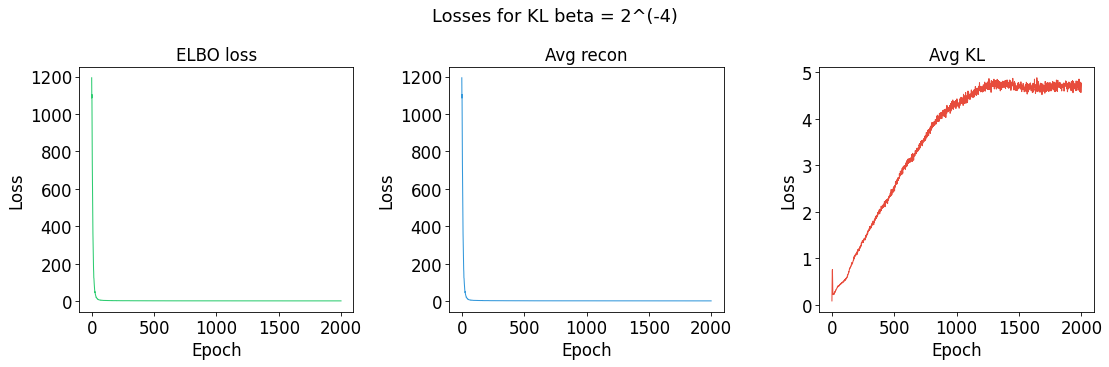

In [8]:
%matplotlib inline
from torch.utils.data import TensorDataset, DataLoader

# Corresponding manifold trajectories (flattened)
betas = np.array(betas_aligned_all) # (N, K, M, T)
X_man = torch.from_numpy(betas.reshape(betas.shape[0], -1).astype(np.float32)).to(device=device, dtype=dtype)

D = tangent_flat.shape[0]
R = 6
betakl = 2**(-4)
num_epochs = 2000

dataset = TensorDataset(
    torch.from_numpy(tangent_flat.T.astype(np.float32)),
    torch.from_numpy(betas.reshape(betas.shape[0], -1).astype(np.float32))
)

# Use CUDA generator to match torch.set_default_device('cuda:1') from functionsgpu_old
g = torch.Generator(device=device).manual_seed(SEED)
loader = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=False, generator=g)

deterministic()
base_vae = NonlinearVAE(D, R).to(device=device, dtype=dtype)
model = KTRSV(base_vae, mu_shape, exp_gpu_batch).to(device=device, dtype=dtype)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

elbo_losses = []
avgrecon_losses = []
avgkl_losses = []

for epoch in tqdm(range(num_epochs)):
    epoch_elbo, epoch_recon = 0, 0 
    epoch_kl, num_samples = 0, 0

    for x_tan_batch, x_man_batch in loader:
        x_tan_batch = x_tan_batch.to(device)
        x_man_batch = x_man_batch.to(device)
        opt.zero_grad(set_to_none=True)

        # forward in tangent space, loss in manifold space
        x_hat_man, mu, logvar, z, v_hat = model(x_tan_batch)
        elbo_loss, avgrecon, avgkl = ktrsv_loss(x_man_batch, x_hat_man, 
                                                mu, logvar, beta=betakl)

        elbo_loss.backward()
        opt.step()

        # accumulate for logging
        batch_size = x_tan_batch.size(0)
        epoch_elbo += elbo_loss.item() * batch_size
        epoch_recon += avgrecon.item() * batch_size
        epoch_kl += avgkl.item() * batch_size
        num_samples += batch_size

    elbo_losses.append(epoch_elbo / num_samples)
    avgrecon_losses.append(epoch_recon / num_samples)
    avgkl_losses.append(epoch_kl / num_samples)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
epochs = range(len(elbo_losses))

axes[0].plot(epochs, elbo_losses, color='#2ecc71')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('ELBO loss')

axes[1].plot(epochs, avgrecon_losses, color='#3498db')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Avg recon')

axes[2].plot(epochs, avgkl_losses, color='#e74c3c')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('Avg KL')

exp = int(np.log2(betakl))
plt.suptitle(f'Losses for KL beta = 2^({exp})')
plt.tight_layout()
folder = f"2^{exp}"
# plt.savefig(f'result_figures/{folder}/loss_plot.png')
plt.show()

In [8]:
# %matplotlib qt5
# plot_one_traj(x_hat_man[1,:].reshape(32,3,tslen))

In [9]:
model.eval()
with torch.no_grad():
    # latent means for the tangent-input rVAE
    def rvae_encode(x):
        mu, logvar = model.vae.encode(x)
        return mu, logvar

    def rvae_decode(z):
        return model.vae.decode(z.float())

In [38]:
# %matplotlib inline
# Tangent input
# X_tan = torch.from_numpy(tangent_flat.T.astype(np.float32)).to(device=device, dtype=dtype)

# for i in range(20):
#     plt.figure()
#     model.eval()
#     with torch.no_grad():
#         mu_all, logvar_all = rvae_encode(X_tan)
#         sigma_all = torch.exp(0.5 * logvar_all)
#         eps = torch.randn_like(sigma_all)
#         z_sample = mu_all + sigma_all * eps

#         z = z_sample.cpu().numpy()
#         zdf = pd.DataFrame(z, columns=["z{}".format(i+1) for i in range(z.shape[1])])
#         zdf.loc[0:44,'Cohort'] = 'Stroke'
#         zdf.loc[44:,'Cohort'] = 'Healthy'

#         # sorting by variance
#         latent_cols = [c for c in zdf.columns if c.startswith("z")]
#         zdf = zdf[zdf[latent_cols].var().sort_values(ascending=False).index.tolist() + ["Cohort"]]
#         zdf = zdf.rename(columns={col: f"z{i+1}" for i, col in enumerate(zdf.columns[:-1])})

        # fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        # sns.scatterplot(data=zdf, x='z1', y='z2', hue='Cohort', ax=axes[0])
        # sns.heatmap(zdf.loc[:,:'z5'].corr(), fmt=".1f", annot=True, vmin=-1, vmax=1, ax=axes[1])
        # plt.suptitle(f'Scatter plot and correlation heatmap for KL $\\beta = 2^{{{exp}}}$, '
        # r'$\mathbf{z} = \mathbf{\mu} + \mathbf{\sigma} \odot \mathbf{\epsilon}$')
        # plt.tight_layout()
        # plt.show()

In [18]:
%matplotlib inline
X_tan = torch.from_numpy(tangent_flat.T.astype(np.float32)).to(device=device, dtype=dtype)
with torch.no_grad():
    mu_all, logvar_all = rvae_encode(X_tan)
z = mu_all.cpu().numpy()
zdf = pd.DataFrame(z, columns=["z{}".format(i+1) for i in range(z.shape[1])])
zdf.loc[0:44,'Cohort'] = 'Stroke'
zdf.loc[44:,'Cohort'] = 'Healthy'

# sorting by variance
latent_cols = [c for c in zdf.columns if c.startswith("z")]
zdf = zdf[zdf[latent_cols].var().sort_values(ascending=False).index.tolist() + ["Cohort"]]
zdf = zdf.rename(columns={col: f"z{i+1}" for i, col in enumerate(zdf.columns[:-1])})

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# sns.scatterplot(data=zdf, x='z1', y='z2', hue='Cohort', ax=axes[0], s=60)
# axes[0].set_xlabel(r"$z_1$")
# axes[0].set_ylabel(r"$z_2$")
# axes[0].legend(loc='upper left')

# sns.heatmap(zdf.loc[:,:'z5'].corr(), fmt=".1f", annot=True, vmin=-1, vmax=1, ax=axes[1],
#             cmap=sns.diverging_palette(0, 255, sep=77, as_cmap=True))
# axes[1].set_xticklabels([r"$z_1$", r"$z_2$", r"$z_3$", r"$z_4$", r"$z_5$"])
# axes[1].set_yticklabels([r"$z_1$", r"$z_2$", r"$z_3$", r"$z_4$", r"$z_5$"])
# plt.suptitle(f'Scatter Plot and Correlation Heatmap for Latent Variables '
#              r'$(\mathbf{z} = \mathbf{\mu})$')

       
# plt.tight_layout()
# plt.savefig(f'result_figures/{folder}/scatter_heatmap.png',bbox_inches='tight',dpi=300)
# plt.savefig(f'result_figures/{folder}/scatter_heatmap.eps',bbox_inches='tight')
# plt.show()

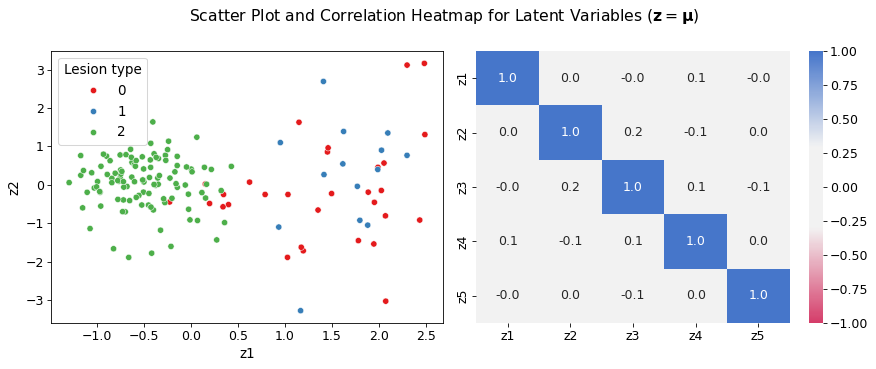

In [50]:
%matplotlib inline
zdf = pd.DataFrame(z, columns=["z{}".format(i+1) for i in range(z.shape[1])])
zdf.loc[:,'Lesion type'] = y_lesion

# sorting by variance
latent_cols = [c for c in zdf.columns if c.startswith("z")]
zdf = zdf[zdf[latent_cols].var().sort_values(ascending=False).index.tolist() + ['Lesion type']]
zdf = zdf.rename(columns={col: f"z{i+1}" for i, col in enumerate(zdf.columns[:-1])})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=zdf, x='z1', y='z2', hue='Lesion type', ax=axes[0], palette='Set1')
sns.heatmap(zdf.loc[:,:'z5'].corr(), fmt=".1f", annot=True, vmin=-1, vmax=1, ax=axes[1],
            cmap=sns.diverging_palette(0, 255, sep=77, as_cmap=True))
plt.suptitle(f'Scatter Plot and Correlation Heatmap for Latent Variables '
             r'$(\mathbf{z} = \mathbf{\mu})$')

plt.tight_layout()
plt.savefig(f'result_figures/{folder}/scatter_heatmap2.png',bbox_inches='tight',dpi=300)
plt.savefig(f'result_figures/{folder}/scatter_heatmap2.eps',bbox_inches='tight')
plt.show()
plt.show()

In [52]:
# from clf import *
# results_test_df = clf(zdf, y_lesion, participant_ids)
# results_test_df

In [10]:
%matplotlib qt5

k = 3  # number of stds
scales = [-k, 0, k]
betas_hat = []
p_all = []
mode_variances = []

for dim in range(R):
    z_plot = np.zeros((1,R))
    for s in scales:
        z_plot[0, dim] = s

        with torch.no_grad():
            v = rvae_decode(torch.from_numpy(z_plot).to(device))
        if s == k:
            mode_variances.append(np.var(v.cpu().numpy()))
            
        v = v.reshape(K, M, T)
        beta_hat = exp_gpu(mu_all_t_tensor, v)
        betas_hat.append(beta_hat.detach().cpu().numpy())

    p = plotting_betas_landmark([betas_hat[-3], betas_hat[-2], betas_hat[-1]],
                                 colors=[(1, 0, 0), (0, 0, 0), (0, 0.5, 1)])
    p_all.append(p)

mode_variances = np.array(mode_variances)
idx = np.argsort(mode_variances)[::-1] # sorting
mode_variances_sorted = mode_variances[idx]
p_all_sorted = [p_all[i] for i in idx]

libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast


In [15]:
folder = 'modes'
for dim, p in enumerate(p_all_sorted):
    filename = f"result_figures/{folder}/mode_{dim+1}"
    # video_saving(p, filename)
    p.to_image(filename + ".png")
    # p.to_image(filename + ".eps")
    p.close()

In [13]:
zdf.to_csv(f"result_figures/{folder}/zdf_R38.csv",index=False)

In [ ]:
# %matplotlib qt5

# k = 3  # number of stds
# scales = [-k, 0, k]
# betas_hat = []
# p_all = []
# mode_variances = []

# for dim in range(R):
#     z_plot = np.zeros((1,R))
#     for s in scales:
#         z_plot[0, dim] = s

#         with torch.no_grad():
#             v = rvae_decode(torch.from_numpy(z_plot).to(device))
#         if s == k:
#             mode_variances.append(np.var(v.cpu().numpy()))
            
#         v = v.reshape(K, M, T)
#         beta_hat = exp_gpu(mu_all_t_tensor, v)
#         betas_hat.append(beta_hat.detach().cpu().numpy())

#     p = plotting_betas_landmark([betas_hat[-3], betas_hat[-2], betas_hat[-1]],
#                                  colors=[(1, 0, 0), (0, 0, 0), (0, 0.5, 1)])

In [ ]:
# folder = 'modes'
# filename = f"result_figures/{folder}/mode_1"
# p.to_image(filename + ".png")
# p.to_image(filename + ".eps")